# Ciencia de datos - Laboratorio 03
## Visualización y EDA
## Iván Abrego Islas

In [1]:
import plotly
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
full = pd.read_pickle("full.pkl")

## 1. Definir cohorte de interés - pacientes con COVID-19

In [3]:
conditions = pd.read_csv('conditions.csv')

In [4]:
covid_mask = conditions[(conditions['DESCRIPTION'] == 'COVID-19')]['PATIENT']

In [5]:
covid = full[full['patient'].isin(covid_mask)]
del conditions, covid_mask, full

## 2. Ejecutar EDA checklist 

| EDA checklist |
|---------------|
| 1. ¿Qué forma y qué tipos tiene? |
| 2. ¿Qué falta y con qué patrón? |
| 3. ¿Cómo se distribuye cada variable? |
| 4. ¿Hay valores imposibles? |
| 5. ¿Cómo se relacionan entre sí? |
| 6. ¿Cambia con el tiempo o el sitio? |
| 7. ¿Hay datos suficientes para explicar? |

#### 1. ¿Qué forma y qué tipos tiene?

In [6]:
print(covid.shape), print(len(covid['patient'].unique()));

(1619966, 33)
8820


Contamos con aprox. 1.6 M de observaciones que vienen de 8820 pacientes diagnosticados con COVID-19.

In [7]:
covid.dtypes

encounter                           object
start                  datetime64[ns, UTC]
stop                   datetime64[ns, UTC]
patient                             object
organization                      category
provider                          category
payer                             category
encounterclass                    category
enc_code                          category
enc_desc                          category
base_encounter_cost                float32
total_claim_cost                   float32
payer_coverage                     float32
reasoncode                         float64
reasondescription                 category
date                        datetime64[ns]
obs_code                          category
obs_desc                          category
units                             category
num_val                            float32
non_num_val                       category
birthdate                   datetime64[ns]
deathdate                   datetime64[ns]
ssn        

Estos dtypes ya los conocía ya que yo los definí en el laboratorio anterior, pero no está de más tenerlos a la mano

#### 2. ¿Qué falta y con qué patrón?

In [8]:
# Aca primero selecciono algunas columnas de interes para no trabajar con el dataset completo 
cols = ['encounter', 'start', 'stop', 'patient', 'enc_code', 'enc_desc', 'date', 'obs_code', 'obs_desc',
        'units', 'num_val', 'non_num_val', 'birthdate', 'deathdate', 'race', 'ethnicity', 'gender']
covid = covid[cols]

In [9]:
rng = np.random.default_rng(42)
x = covid['patient'].drop_duplicates().sample().item() # selecciono un paciente al azar

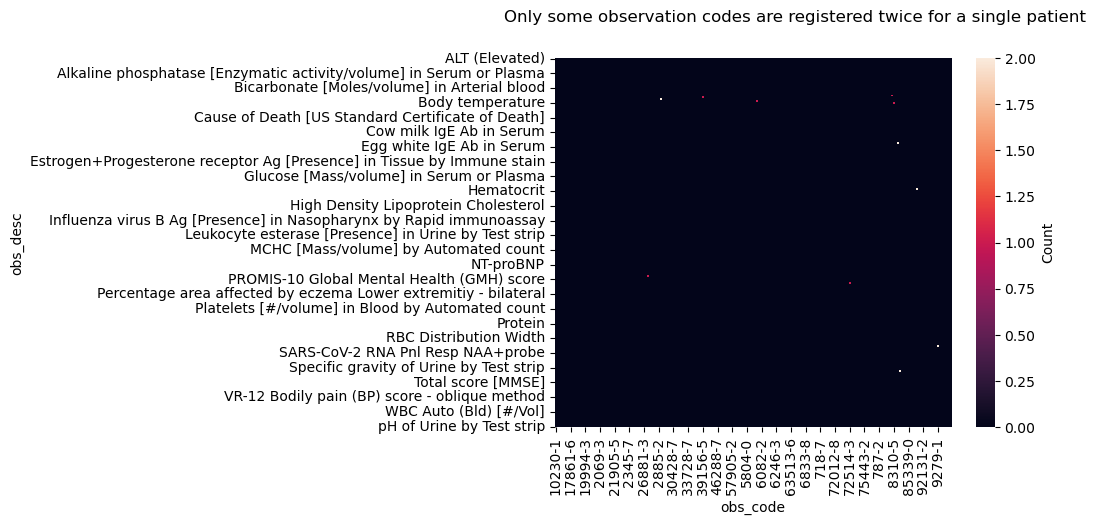

In [10]:
fig, ax = plt.subplots()
sns.heatmap(
    covid[covid['patient'] == x].pivot_table(
        index='obs_desc',
        columns='obs_code',
        values='num_val',
        aggfunc='count',   # cuento cuantas observaciones de cierto codigo tiene cada paciente
        observed=False),   #  aggfunc = mean oscurece observaciones con valores de unidades vs valores de decenas/centenas
        ax = ax,
        cbar_kws={'label': 'Count'}
    #annot=True
);
del x
fig.suptitle('Only some observation codes are registered twice for a single patient');

Esta primera aproximacion, eligiendo un paciente al azar y contando cuantas observaciones tiene de cada codigo, me permite hacerme una idea de la organizacion del dataset y las observaciones hechas por paciente. Aunque hay mucha variabilidad, puedo deducir que a cada paciente solo se le hacen ciertos tests cierta cantidad de veces. Esto me indica que hay muchos valores vacios que coincidirian con las mediciones que no se le hicieron a cierto paciente pero de cualquier manera aparecene en el dataset ya que a otro paciente sí se le hicieron. Esto me permite hacerme una idea de como debo aproximarme a los datos para cuidar las entradas duplicadas (e.g. encuentros y pacientes repetidos ya que cuentan con varias observaciones) y los datos faltantes.

In [11]:
top10 = covid['obs_desc'].value_counts().head(10).index

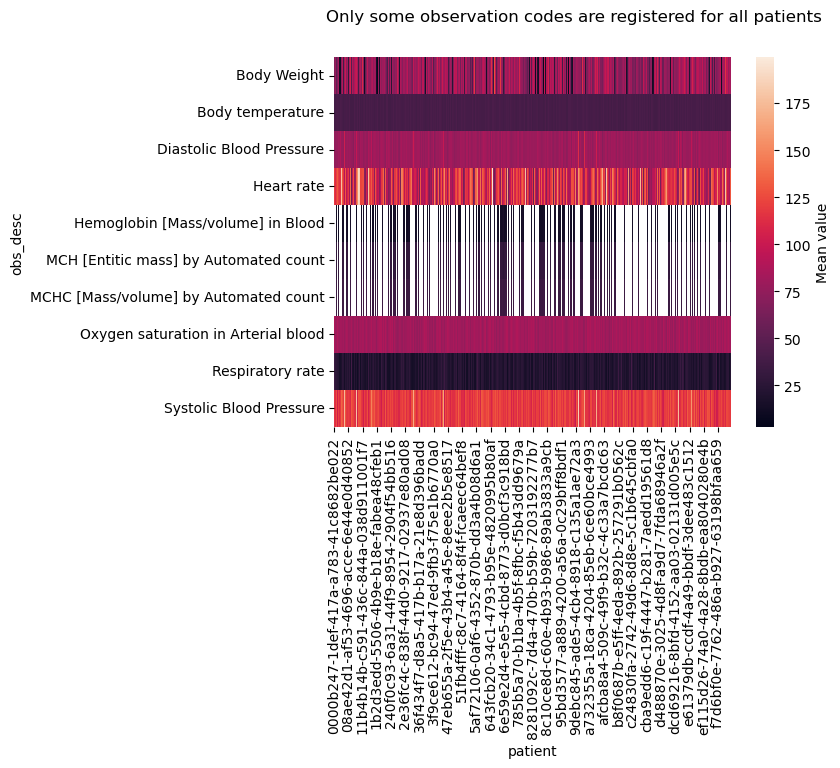

In [12]:
fig, ax = plt.subplots()
sns.heatmap(
    (covid[covid['obs_desc']
        .isin(top10)]
    ).pivot_table(
        index = 'obs_desc',
        columns = 'patient',
        values = 'num_val',
        aggfunc = 'mean',
        observed = True
    ),
    ax = ax,
    cbar_kws={'label': 'Mean value'}
);
fig.suptitle('Only some observation codes are registered for all patients');

Aunque bastante fea, esta grafica me ayuda a entender la distribucion de observaciones para los 10 codigos mas comunes: Hemoglobin, MCH, y platelets, a pesar de estar entre los 10 codigos mas frecuentes, no fueron registrados para todos los pacientes. Por otro lado, el resto de las variables del eje Y parecen tener mediciones para todos y cada uno de los ~8k pacientes.

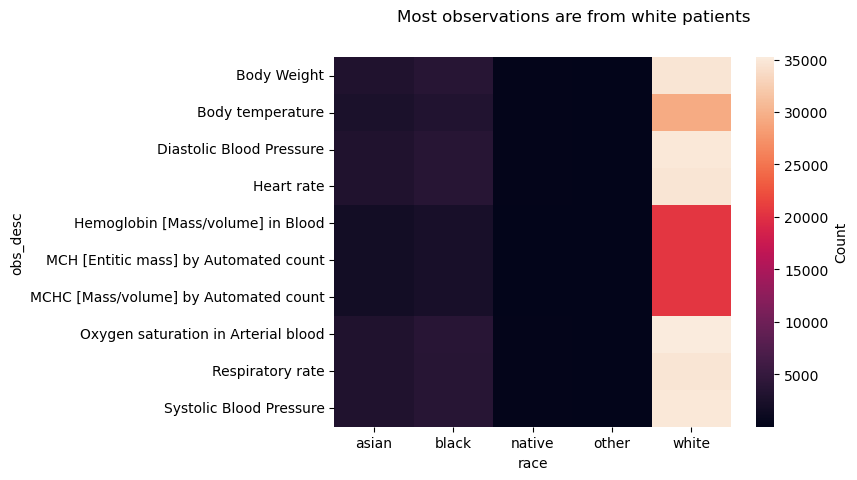

In [13]:
fig, ax = plt.subplots()
sns.heatmap(
    covid[covid['obs_desc'].isin(top10)].pivot_table(
        index = 'obs_desc',
        columns = 'race',  
        values = 'num_val',
        aggfunc = 'count',
        observed = True
    ),
    cbar_kws={'label': 'Count'},
    ax = ax
);
fig.suptitle('Most observations are from white patients');

Interesante, con esta grafica puedo ver que la gran mayoria de observaciones (entre 20k y 35k) se hichieron para raza blanca, mientras que el resto de razas tienen entre 5k y 10k observaciones.

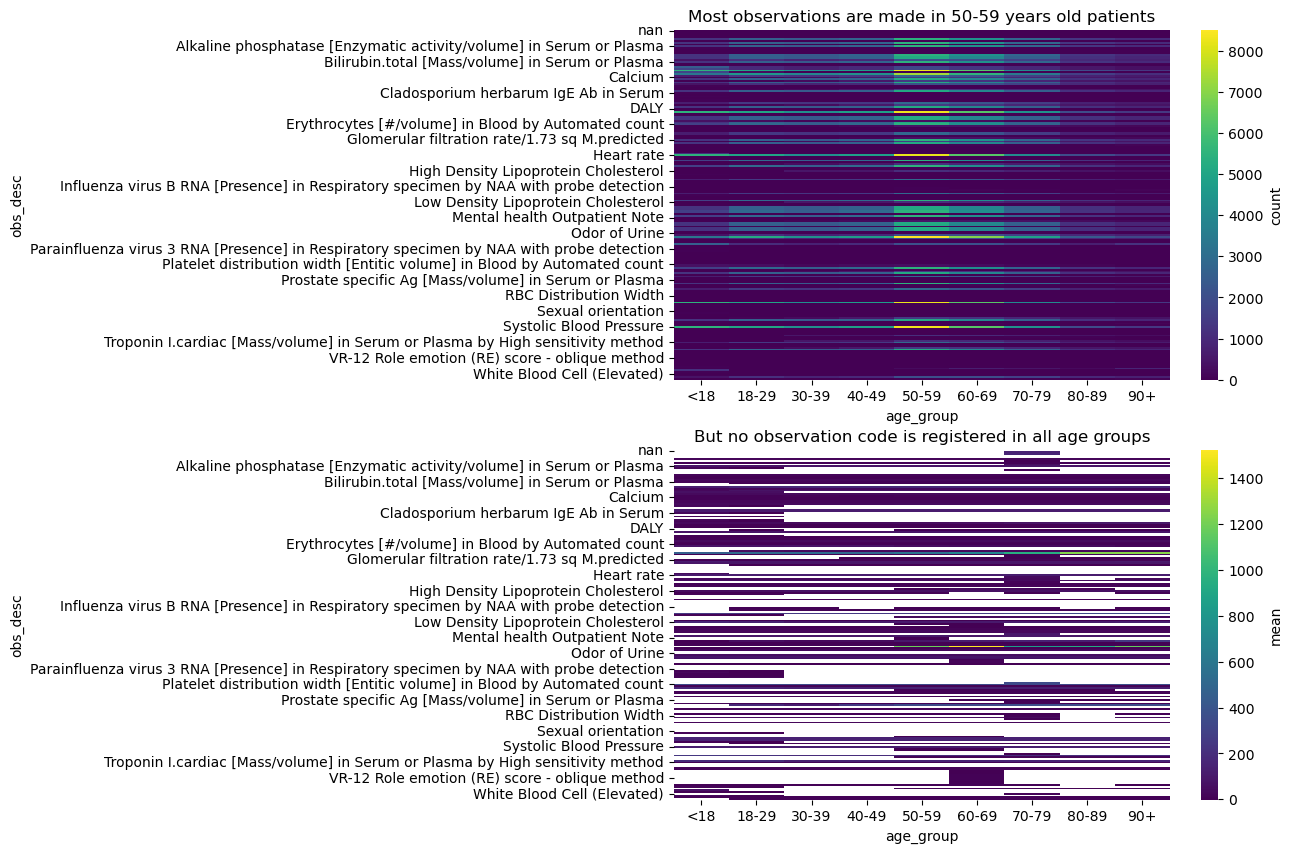

In [14]:
#age_groups = ['0-5', '5-10', '11-18', '18-29', '30-59', '60-80', '80+']
age_bins = [0, 18, 30, 40, 50, 60, 70, 80, 90, 110]
age_labels = ['<18', '18-29', '30-39', '40-49','50-59', '60-69','70-79', '80-89','90+']
covid['age_at_obs'] = (covid['date'] - covid['birthdate']).dt.days / 365
covid['age_group'] = pd.cut(covid['age_at_obs'],
                            bins=age_bins,
                            labels=age_labels,
                            right=False
                           )
fig, axs = plt.subplots(2, 1, figsize=(8,10))
aggfuncs = ('count', 'mean')
for i, ax in enumerate(axs.flatten()):
    sns.heatmap(covid
        .pivot_table(index = 'obs_desc',
                     columns = 'age_group',
                     values = 'num_val',
                     aggfunc = aggfuncs[i],
                     observed = False,
                     dropna = False
                    ),
                cmap = 'viridis',
                fmt = '.1f',
                ax = ax,
                cbar_kws={'label': aggfuncs[i]}
               );
axs[0].set_title('Most observations are made in 50-59 years old patients');
axs[1].set_title('But no observation code is registered in all age groups');

La primera grafica (con aggfunc='count') me dice cuantas observaciones de cada codigo se hicieron por edad. Es interesante que el grupo de edad con mayor cantidad de observaciones es el de 50-69 años. La segunda grafica tiene código prácticamente idéntico, con la única diferencia de que usa aggfunc='mean' en vez de 'count'. Dado que hay códigos sin observaciones en ciertos grupos de edad, el conteo resulta en 0, pero estos pueden ser difíciles de distinguir de códigos con muy pocas observaciones. En ese caso calcular la media en vez del conteo resulta útil, ya que el manejo de NaNs es distinto y deja una celda vacía en caso de ser necesario. Esto me permite identificar en qué grupos de edad debo esperar ciertos códigos de observación y en cuáles debo esperar NaNs. También debo tomar en cuenta que yo separé manualmente hacia otra columna las observaciones cuyo valor o resultado no fuera numérico. Quiere decir que, por ejemplo, Odor of urine o Sexual orientation no necesariamente no fueron capturados para ningún grupo de edad, sino que su respuesta está guardada en otra columna que en este caso no estoy usando para gráficar. Por ultimo quiero ver una gráfica similar a las anteriores pero haciendo zoom sobre las observaciones mas comunes

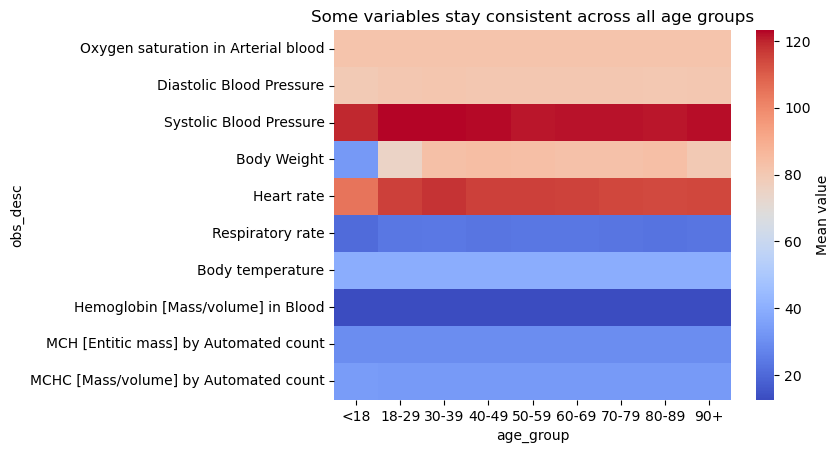

In [15]:
fig, ax = plt.subplots()
sns.heatmap(covid[covid['obs_desc'].isin(top10)]
    .pivot_table(index = 'obs_desc',
                 columns = 'age_group',
                 values = 'num_val',
                 aggfunc = 'mean',
                 observed = False,
                 dropna = False
                )
    .reindex(top10),
            cmap = 'coolwarm',
            fmt = '.1f',
            ax = ax,
            cbar_kws={'label': 'Mean value'}
           );
ax.set_title('Some variables stay consistent across all age groups');

Aca puedo ver que para los 10 códigos más observados, no tengo valores faltantes para ningún grupo de edad. También es interesante ver como algunas variables se mantienen constantes para todos los grupos de edad, mientras que, HEart rate por ejemplo, parece ir aumentando conforme la edad aumenta.

#### 3. ¿Cómo se distribuye cada variable? y 5. ¿Cómo se relacionan entre sí? 

Nota: tammbién seleccionaré únicamente algunas variables de interés

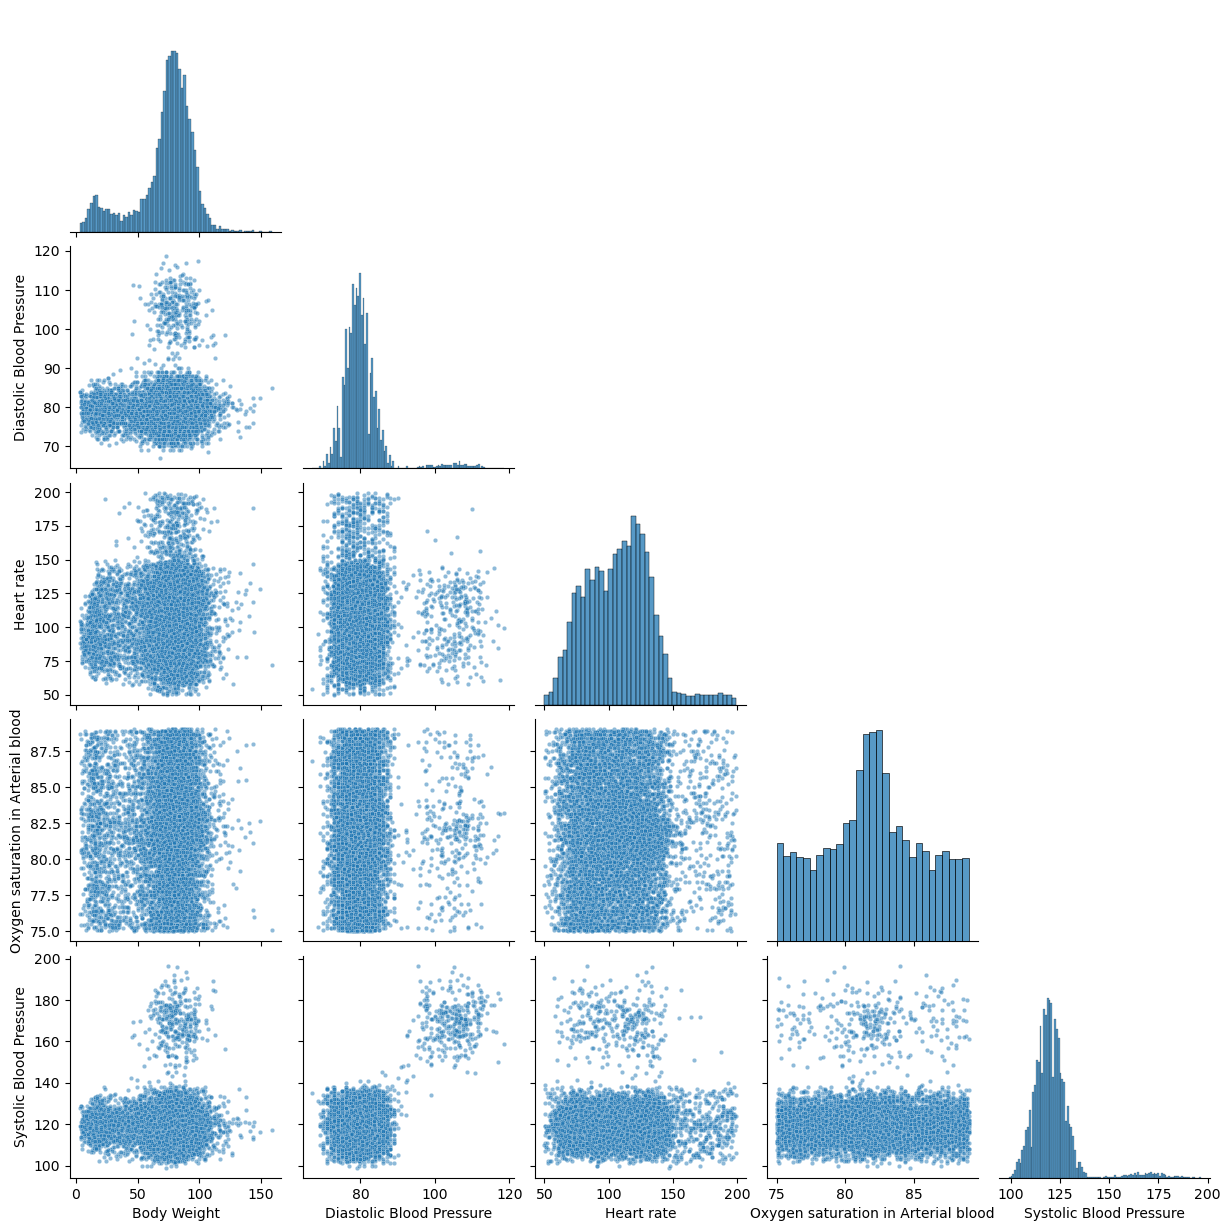

In [16]:
#fig, ax = plt.subplots()
sns.pairplot(
    covid[covid['obs_desc'].isin(top10[:5])]
    .pivot_table(
        index = 'patient',
        columns = 'obs_desc',
        values = 'num_val',
        aggfunc = 'mean',
        observed = False
    )
    .dropna(),
    diag_kind = 'hist',
    plot_kws = {'alpha': 0.5,
                's': 10},
    corner = True,
);

Esta grafica me permite ver para algunas variables de interes (los 5 códigos de observación más frecuentes) su distribución, así como explorar posibles correlaciones con otras variables. A pesar de que el volumen de datos puede dificultar un poco la visualización, en algunos casos podemos distinguir patrones por ejemplo. Por ejemplo, al graficar diastolic blood pressure contra systolic blood pressure (última fila, primera columna) puedo ver que en ambas se separa una seguna población más pequeña de puntos, lo cual tambien se hace evidente en los histogramas de distribución. Esto probablemente apunta hacia valores implausibles que salen del rango fisiólogico, lo verifico más adelante. Oxygen saturation parece tener un número constante de observaciones dentro de cierto rango, con solo un pequeño cúmulo separándose del resto de la población debido a los probables valores implausibles de systolic blood pressure (última fila, tercera columna). Este patrón de del pequeño cúmulo que se separa debido a systolic blood pressure se repite para heart rate y respiratory rate (ultima columna, segunda y cuarta columnas). Pero en estos casos, también se separa un segundo cúmulo de la población principal, hacia magnitudes mayores de ambas frecuencias, los cuales también habría que evaluar si salen del rango fisiológico.

#### 4. ¿Hay valores imposibles?

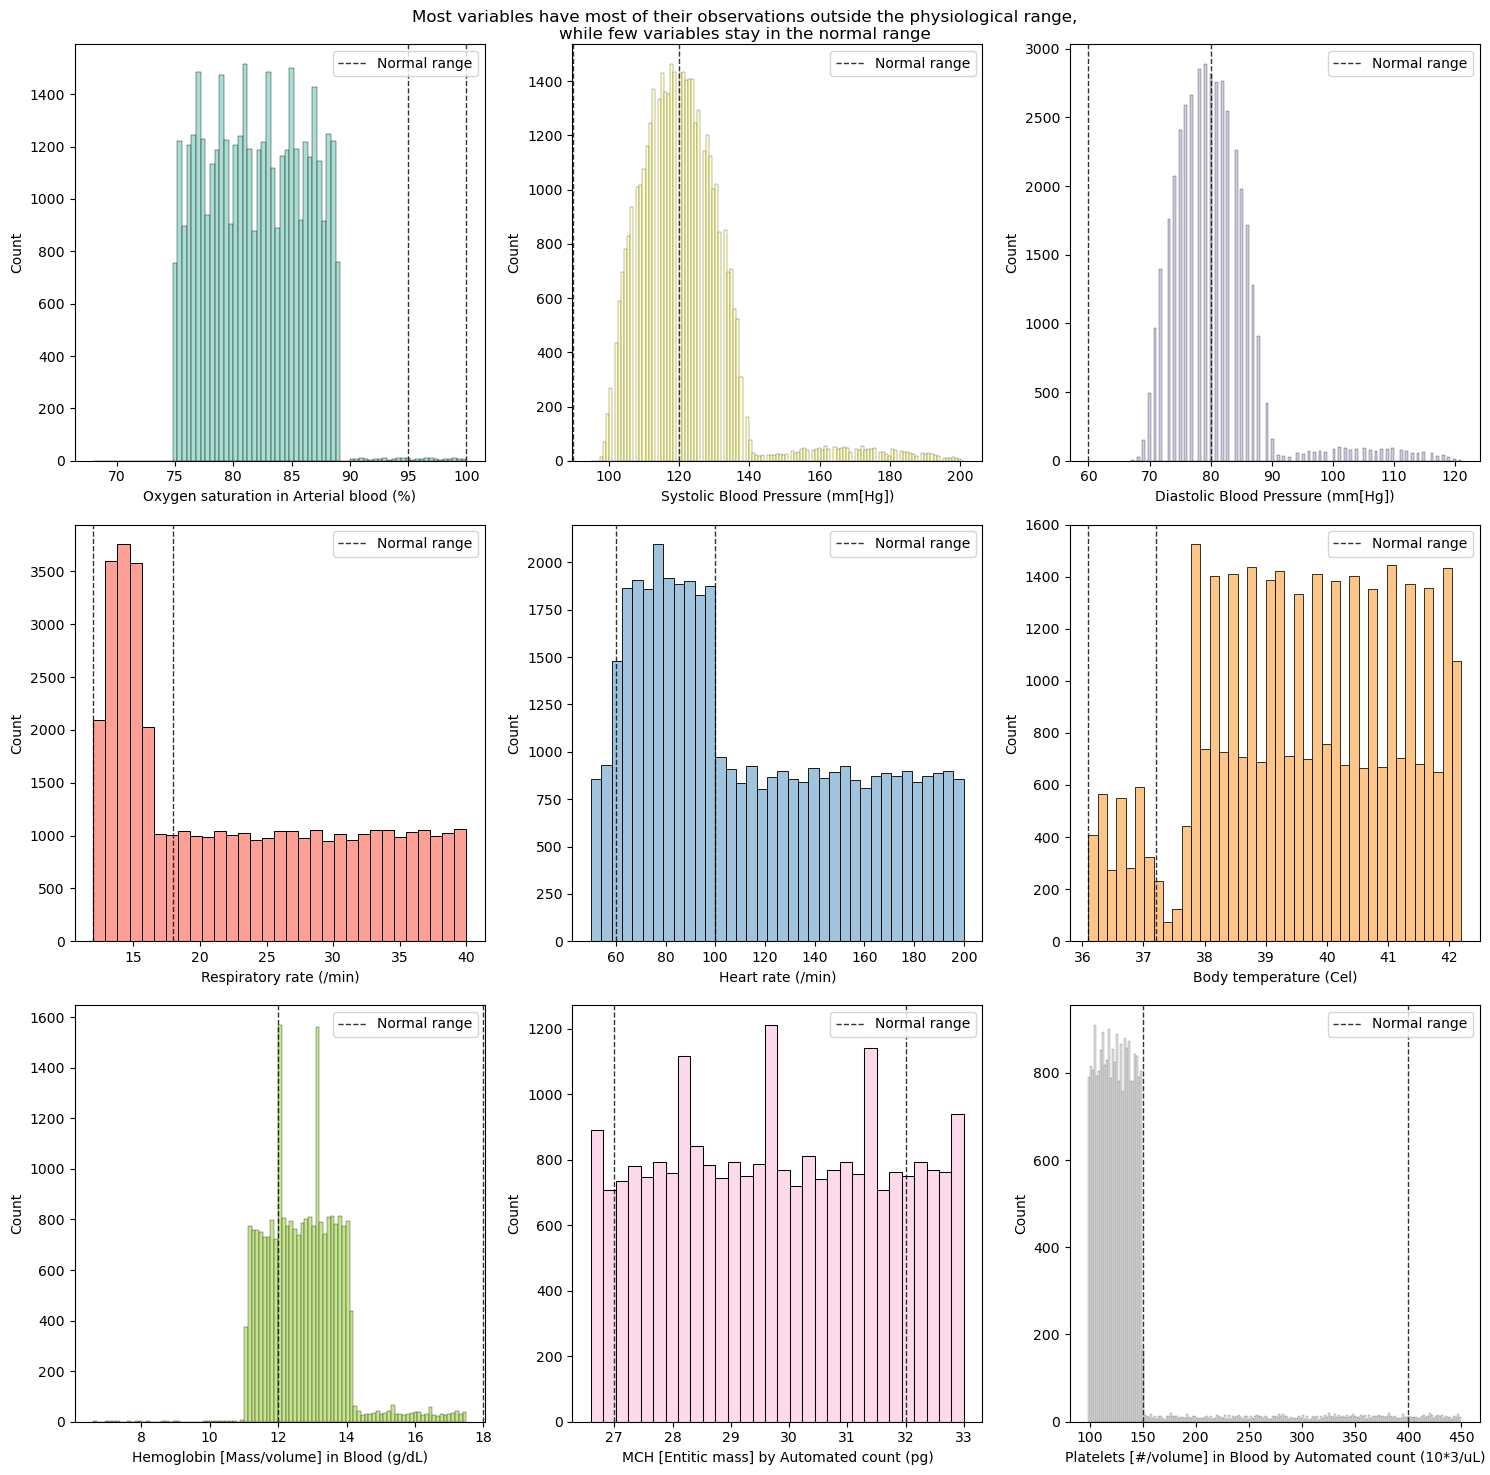

In [17]:
x = ['Oxygen saturation in Arterial blood',
    'Systolic Blood Pressure',
    'Diastolic Blood Pressure',
    'Respiratory rate',
    'Heart rate',
    'Body temperature',
    'Hemoglobin [Mass/volume] in Blood',
    'MCH [Entitic mass] by Automated count',
    'Platelets [#/volume] in Blood by Automated count'] # quito body weight pq hay mucha variabilidad por edad, sexo, etc
colors = ['#8dd3c7',
'#ffffb3',
'#bebada',
'#fb8072',
'#80b1d3',
'#fdb462',
'#b3de69',
'#fccde5',
'#d9d9d9']
physio_ranges = dict(zip(x,
                         [(95, 100), # oxygen [1]
                          (90, 120), # sys [2]
                          (60, 80), # dias [3]
                          (12, 18), # resp [4]
                          (60, 100), # heart [5]
                          (36.1, 37.2), # temp [6]
                          (12, 18), # hemoglobin [7]
                          (27, 32), # MCH [8]
                          (150, 400)])) # platelets [9] 10**3
fig, axs = plt.subplots(3, 3, figsize=(15,15))
data = covid[covid['obs_desc'].isin(x)].groupby('obs_desc', observed=False)
#units = data['units'].drop_duplicates().astype('string').to_list()
x = iter(x)
for i, ax in enumerate(axs.flatten()):
    xx = next(x)
    group = data.get_group(xx)
    sns.histplot(x = group['num_val'],
                 ax = ax,
                 fill = True,
                 color = colors[i])
    ax.axvline(physio_ranges[xx][0], ls='--', alpha=0.8, color='k', lw=1, label='Normal range')
    ax.axvline(physio_ranges[xx][1], ls='--', alpha=0.8, color='k', lw=1)
    ax.set_xlabel(f'{xx} ({group['units'].drop_duplicates().astype('string').item()})');
    ax.legend(loc='upper right');
fig.suptitle('Most variables have most of their observations outside the physiological range,\nwhile few variables stay in the normal range')
fig.tight_layout();


[1]: https://www.sciencedirect.com/topics/immunology-and-microbiology/arterial-oxygen-saturation
[2]: https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings
[3]: https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings
[4]: https://my.clevelandclinic.org/health/articles/10881-vital-signs
[5]: https://my.clevelandclinic.org/health/articles/10881-vital-signs
[6]: https://medlineplus.gov/ency/article/001982.htm
[7]: https://www.medicinenet.com/hemoglobin/article.htm
[8]: https://emedicine.medscape.com/article/2054497-overview
[9]: https://my.clevelandclinic.org/health/diagnostics/21782-platelet-count

Estas graficas resultan sumamente interesantes. De las 9 variables que exploro aquí, únicamente MCH y Hemoglobin podemos decir que se encuentran mayoritariamente dentro del rango fisiológico. Heart rate y Respiratory rate alcanzan su máximo conteo dentro del rango fisiológico, pero también cuentan con un alto número de observaciones de frecuencias incrementadas (me refiero a frecuencia respiratoria o cardiaca, no frecuencia de estadística jaja). Presión sistólica y diástolica cuentan con aproximadamente el 40% de sus observaciones dentro del rango fisiológico, pero el otro 50% y una cola que corresponde aprox. al 10% se encuentran por encima del umbral superior normal. Las más extremas y preocupantes son Platelets, Body temperature y oxygen saturation, con la gran mayoría (probablemente entre 90% y 99%) de sus observaciones fuera del rango fisiológico. A pesar de no ser experto en el tema, me parece que todas estas gráficas revelan información consistente con la sintomatología esperada en un paciente diagnosticado con COVID. 

#### Referencias rangos fisiológicos:
1. https://my.clevelandclinic.org/health/diagnostics/22447-blood-oxygen-level (oxygen saturation)
2. https://my.clevelandclinic.org/health/articles/10881-vital-signs (systolic BP)
3. https://my.clevelandclinic.org/health/articles/10881-vital-signs (diastolic BP)
4. https://my.clevelandclinic.org/health/articles/10881-vital-signs (resp. rate)
5. https://my.clevelandclinic.org/health/articles/10881-vital-signs (heart rate)
6. https://my.clevelandclinic.org/health/articles/10881-vital-signs (body temp.)
7. https://www.medicinenet.com/hemoglobin/article.htm (hemoglobin)
8. https://emedicine.medscape.com/article/2054497-overview?form=fpf (MCH)
9. https://my.clevelandclinic.org/health/diagnostics/21782-platelet-count (Platelets)

#### 6. ¿Cambia con el tiempo o el sitio?

In [18]:
covid['date'].dropna().sort_values()

1470914   2019-03-03
74699     2019-03-22
74698     2019-03-22
74697     2019-03-22
74696     2019-03-22
             ...    
246791    2020-05-26
246790    2020-05-26
1634019   2020-05-26
1541567   2020-05-26
1778131   2020-05-27
Name: date, Length: 1443762, dtype: datetime64[ns]

In [19]:
bins = pd.to_datetime(['2019-x-01'.replace('x', i) for i in ['0' + str(i) for i in range(1,10)] + ['10', '11', '12']] + ['2020-x-01'.replace('x', i) for i in ['0' + str(i) for i in range(1,7)]])

In [20]:
bins_labels = list(map(lambda x: x.removesuffix('-01'),(bins.astype('string').to_list())))[:-1]
covid['time_bin'] = pd.cut(
    covid['date'], 
    bins=bins, 
    labels=bins_labels
)

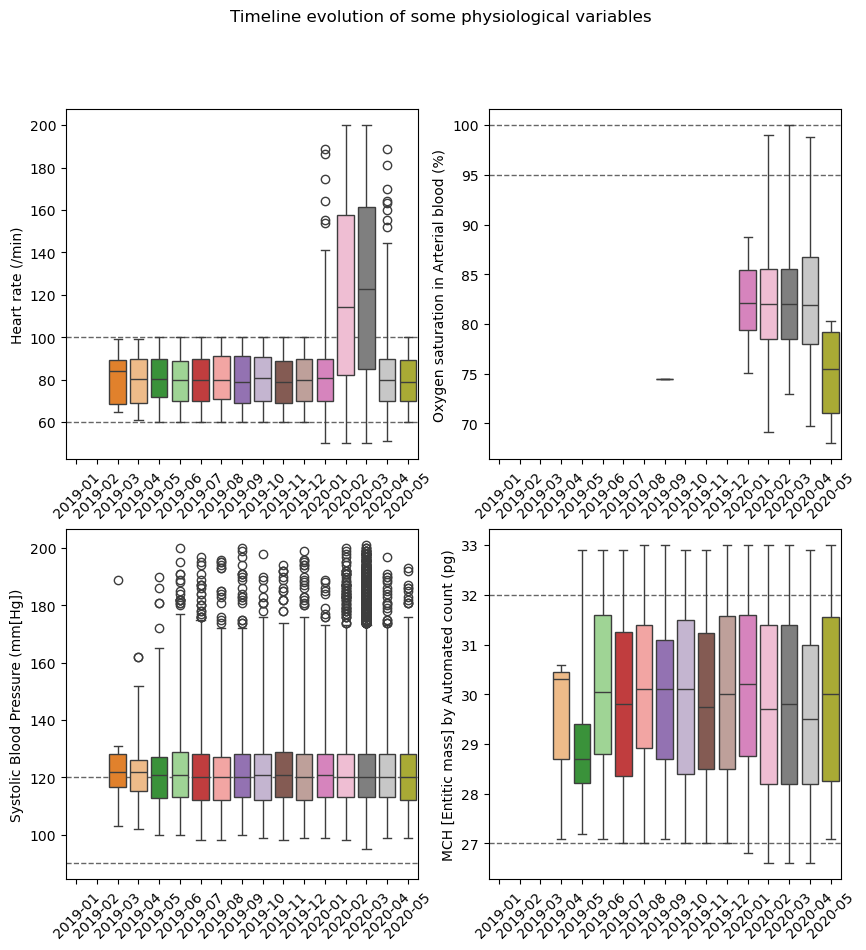

In [21]:
x = ['Heart rate', 'Oxygen saturation in Arterial blood', 'Systolic Blood Pressure', 'MCH [Entitic mass] by Automated count']
fig, axs = plt.subplots(2,2, figsize=(10,10))
data = covid[covid['obs_desc'].isin(x)].groupby('obs_desc', observed=False)
for i, ax in enumerate(axs.flatten()):
    xx = x[i]
    ax.axhline(physio_ranges[xx][0], ls='--', alpha=0.6, color='k', lw=1, label='Normal range')
    ax.axhline(physio_ranges[xx][1], ls='--', alpha=0.6, color='k', lw=1)
    group = data.get_group(xx)
    sns.boxplot(
        data = group,
        x = 'time_bin',
        y = 'num_val',
        hue = 'time_bin',
        palette = 'tab20',
        legend = False,
        dodge = False,
        whis = 3,
        ax=ax
    )
    ax.set_ylabel(f'{xx} ({group['units'].drop_duplicates().astype('string').item()})')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45);
fig.suptitle('Timeline evolution of some physiological variables');

En conjunto con la gráfica anterior, esta gráfica revela información muy interesante. De entrada, heart rate mantiene valores constantes para los primeros meses (bins temporales) dentro del rango fisiológico (lineas punteadas grises), hasta que se llega a los bines 2020-01 y 2020-02. En estos meses, la frecuencia cardaiaca se dispara por encima del rango normal. Esto sugiere que estos bines temporales contienen la mayoría de las observaciones que coinciden con el diagnostico de covid, que es cuando los pacientes presentan esta sintomatología. Esto también se sugiere por la gráfica para saturación de oxígeno, la cual solo presenta esta observación en específico en los bines temporales en los cuales se dispara la frecuencia cardiaca. Esto me hace pensar que esta observación en específico (saturación de oxígeno) no es "rutinaria", sino que únicamente se captura como parte de algunos diagnósticos, como el de COVID-19, lo cual explicaría porque no encontramos esa observación en otros bines temporales. En estos mismos bines temporales es cuando se encuentra mayor cantidad de datos extremos, y por lo tanto mayor variablidad, de las observaciones correspondientes a presión sistólica, sugiriendo también que estos bines podrían coincidir con el diagnóstico de covid el cual resulta en ese aumento de presión. Aunque en ese caso, también es importante mencionar que el resto de bines temporales también tienen observaciones por encima del rango fisiológico. Por otro lado, MCH es la variable que desde la gráfica pasada sospechábamos no se ve afectada por el diagnóstico de COVID-19. Esto es debido a que su distribución se mantiene dentro del rango fisiológico, patrón que vemos repetido dentro de esta evolución temporal.

#### 7. ¿Hay suficientes datos para explicar?

In [22]:
# primero debo extraer el indice, en este caso el inicio del diagnostico de COVID-19
conditions = pd.read_csv('conditions.csv')

In [23]:
covid_start = (conditions
    [conditions['DESCRIPTION'] == 'COVID-19'][['START', 'PATIENT']]
    .rename(columns = {
        'START': 'covid_start',
        'PATIENT': 'patient'})
    .astype({'covid_start': 'datetime64[ns]'})           
              )

In [24]:
covid = covid.merge(covid_start, on='patient', how='left')

In [25]:
post_covid_idx = covid[covid['date'] >= covid['covid_start']]
post_covid_idx = (post_covid_idx
                  .groupby('patient')['date']
                  .count()
                  .reset_index(name='post-covid observations')
)
post_covid_idx = post_covid_idx.reset_index().rename(columns={'index': 'patient #'})

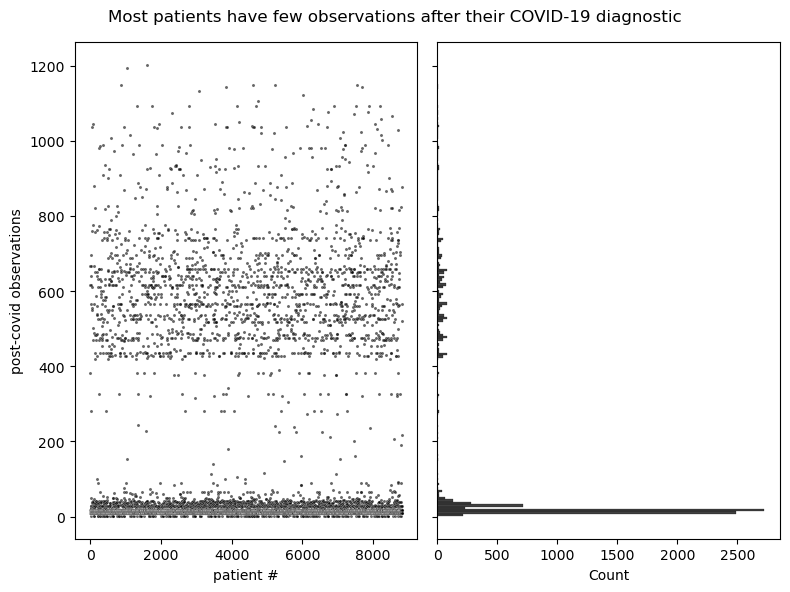

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(8,6), sharey=True)
sns.scatterplot(
    data = post_covid_idx,
    x = 'patient #',
    y = 'post-covid observations',
    alpha = 0.6,
    color = 'k',
    s = 5,
    ax = axs[0]
);
sns.histplot(
    data = post_covid_idx,
    y = 'post-covid observations',
    ax = axs[1],
    color='k'
);
fig.suptitle('Most patients have few observations after their COVID-19 diagnostic');
fig.tight_layout();

Con este par de gráficas puedo ver que la gran mayoría de los pacientes cuentan con, aprox., entre 1 y 50 observaciones tras el diagnóstico por COVID. No obstante, también hay un segundo grupo con muchas más observaciones, entre 400 y 800.

## 3. Distribución de edad por sexo, evolución temporal de un analito, comorbilidades más frecuentes

In [27]:
print(covid['date'].min())
print(covid['date'].max())

2019-03-03 00:00:00
2020-05-27 00:00:00


In [28]:
covid['median_age'] = covid.groupby('patient')['age_at_obs'].transform('median') # primero calculo una edad mediana para cada paciente, ya que tengo un dato de edad al momento de cada observacion

In [29]:
data = (covid
    [['patient', 'gender', 'median_age']]
    .drop_duplicates(subset=['patient'])
    .groupby('gender')
)

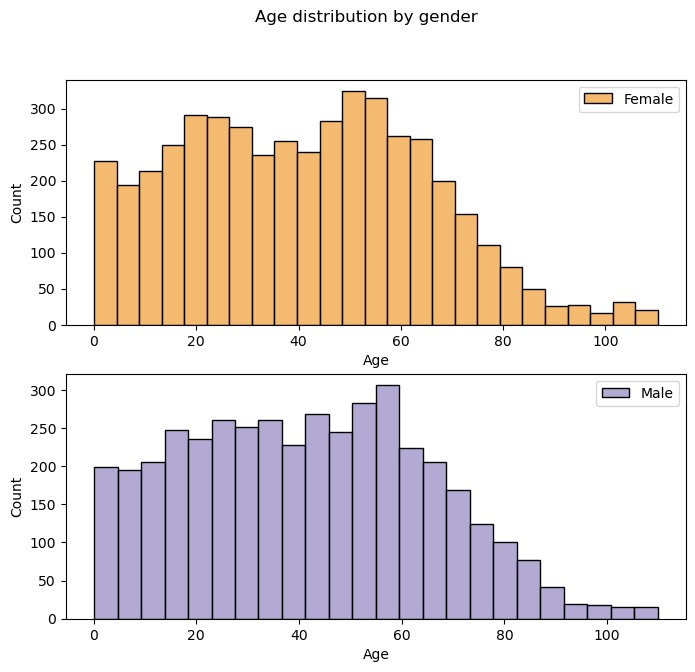

In [30]:
fig, axs = plt.subplots(2, 1, figsize=(8,7))
colors = ('#f1a340', '#998ec3')
x = ('F', 'M')
for i, ax in enumerate(axs.flatten()):
    sns.histplot(
        data = data.get_group(x[i]),
        x = 'median_age',
        label = 'Female' if i == 0 else 'Male',
        legend = True,
        ax = ax,
        color = colors[i]
    )
    ax.set_xlabel('Age')
    ax.legend();
fig.suptitle('Age distribution by gender');

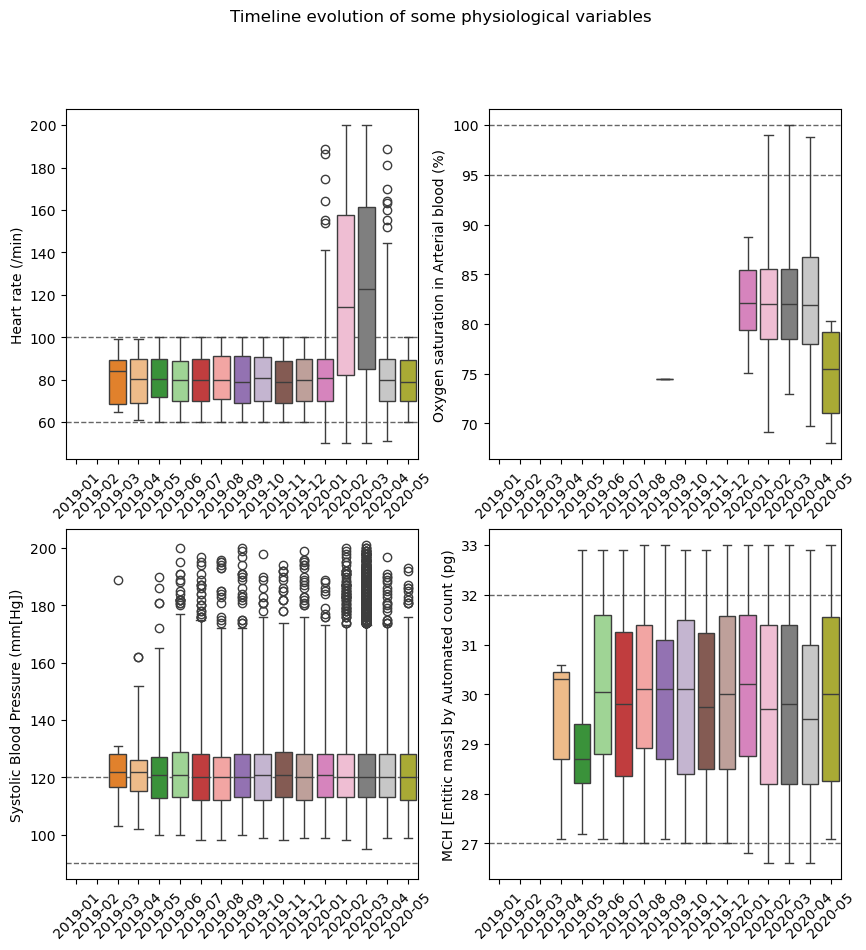

In [31]:
# La evolucion temporal de un analito ya la resolvi anteriormente, aca vuelvo a poner la grafica:
x = ['Heart rate', 'Oxygen saturation in Arterial blood', 'Systolic Blood Pressure', 'MCH [Entitic mass] by Automated count']
fig, axs = plt.subplots(2,2, figsize=(10,10))
data = covid[covid['obs_desc'].isin(x)].groupby('obs_desc', observed=False)
for i, ax in enumerate(axs.flatten()):
    xx = x[i]
    ax.axhline(physio_ranges[xx][0], ls='--', alpha=0.6, color='k', lw=1, label='Normal range')
    ax.axhline(physio_ranges[xx][1], ls='--', alpha=0.6, color='k', lw=1)
    group = data.get_group(xx)
    sns.boxplot(
        data = group,
        x = 'time_bin',
        y = 'num_val',
        hue = 'time_bin',
        palette = 'tab20',
        legend = False,
        dodge = False,
        whis = 3,
        ax=ax
    )
    ax.set_ylabel(f'{xx} ({group['units'].drop_duplicates().astype('string').item()})')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    fig.suptitle('Timeline evolution of some physiological variables');

In [32]:
covid_mask = conditions[conditions['DESCRIPTION'] == 'COVID-19']['PATIENT']

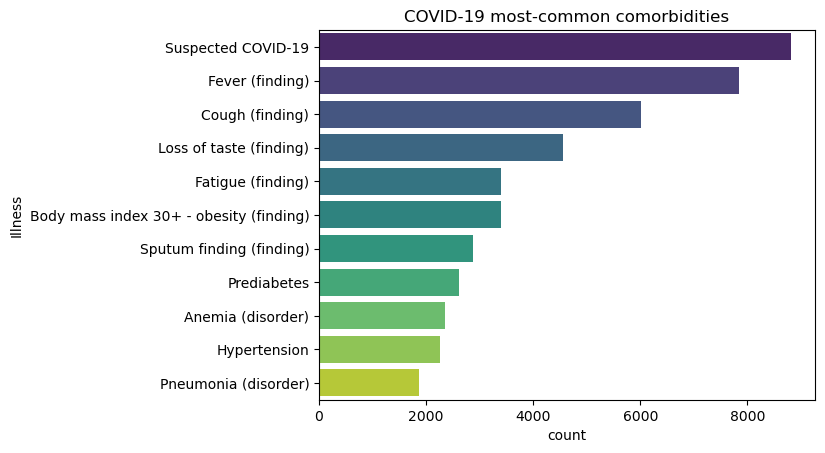

In [33]:
fig, ax = plt.subplots()
sns.barplot(
    data = (
        conditions
            [conditions['PATIENT'].isin(covid_mask)][['DESCRIPTION']]
            .value_counts()
            .drop('COVID-19', level=0)
            .reset_index(name='count')
            .head(11)
            .rename(columns={'DESCRIPTION': 'Illness'})
    ),
    x = 'count',
    y = 'Illness',
    palette = 'viridis',
    hue = 'Illness',
    legend = False,
    ax = ax
)
ax.set_title('COVID-19 most-common comorbidities');

## 4. Detectar al menos dos problemas de calidad que sólo sean visibles graficando, y que no hubieras encontrado con describe()

In [34]:
# Problema 1:
covid[covid['obs_desc'] == 'Oxygen saturation in Arterial blood'][['num_val', 'date']].describe()

,num_val,date
count,42076.000000,42076
mean,82.036545,2020-03-09 16:49:17.619545600
min,68.000000,2019-09-09 00:00:00
25%,78.500000,2020-03-05 00:00:00
50%,82.000000,2020-03-10 00:00:00
75%,85.500000,2020-03-15 00:00:00
max,100.000000,2020-05-15 00:00:00
std,4.140013,NaN


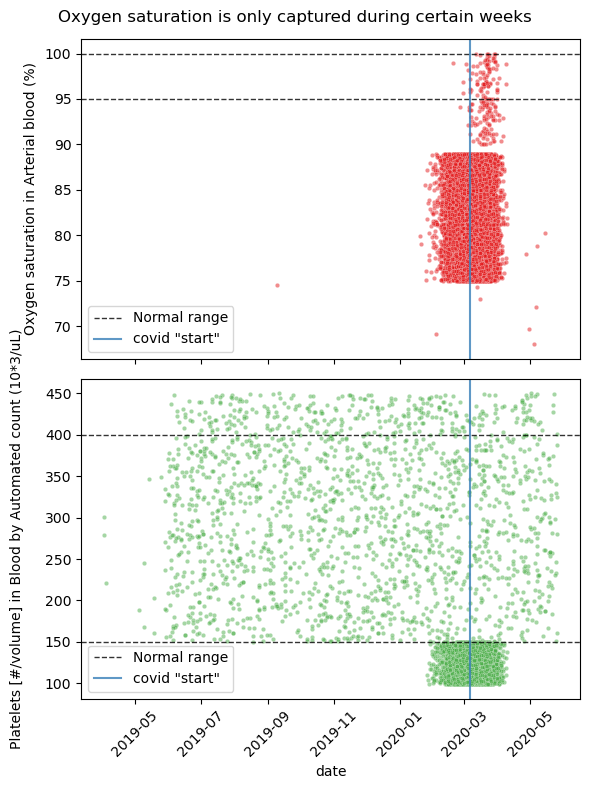

In [35]:
fig, axs = plt.subplots(2,1, figsize=(6,8), sharex=True)
x = ['Oxygen saturation in Arterial blood', 'Platelets [#/volume] in Blood by Automated count']
units = ['%', '10*3/uL']
colors = ['#e41a1c','#4daf4a']
data = covid[covid['obs_desc'].isin(x)][['obs_desc', 'date', 'num_val', 'covid_start']]

for i, ax in enumerate(axs):
    xx = x[i]
    subdata = data[data['obs_desc'] == xx]
    sns.scatterplot(
        data = subdata,
        x = 'date',
        y = 'num_val',
        alpha = 0.5,
        s = 10,
        ax = ax,
        color = colors[i]
    )
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel(xx+f' ({units[i]})', labelpad=5 if i == 0 else 15)
    ax.axhline(physio_ranges[xx][0], ls='--', alpha=0.8, color='k', lw=1, label='Normal range')
    ax.axhline(physio_ranges[xx][1], ls='--', alpha=0.8, color='k', lw=1)
    ax.axvline(data['covid_start'].dropna().median(), label='covid "start"', alpha=0.8, color='#377eb8')
    ax.legend(loc='lower left')
fig.suptitle('Oxygen saturation is only captured during certain weeks')
fig.tight_layout();

**Problema 1:** viendo únicamente el describe() de saturación de oxígeno, lo único que puedo darme cuenta es que tanto su promedio, como sus percentiles se encuentran por debajo del rango fisiológico ideal, mientras que únicamente el valor máximo se encuentra dentro de este rango. Esto únicamente me hace sospechar que esta variable en específico se ve fuertemente afectada por el diagnóstico por covid. No es hasta que graficamos su evolución temporal (panel superior, puntos rojos) y comparamos con otra variable de ejemplo (en este caso Platelets, panel inferior, puntos verdes) que nos damos cuenta que las observaciones de saturación de oxígeno únicamente se hacen cercanas al índice de diagnóstico de COVID (en este caso estoy manejando como índice una fecha mediana de inicio de covid, que podría ser interpretada como la fecha en la cual la mitad de los pacientes del dataset ya habían sido diagnosticados con COVID). Esto sugiere que la saturación de oxígeno únicamente se captura en pacientes que se sospecha padecen de COVID. De igual manera, al graficar así nos damos cuenta de que la variable que usamos como comparación, Platelets, también presenta una gran densidad de observaciones por fuera del rango fisiológico temporalmente cercanas al índice. Por el contrario, en fechas lejanas al índice, esta variable se mantiene mucho más consistentemente dentro del rango normal. Esto confirma que ambas variables fisiológicas se ven afectadas por el diagnostico de COVID y forman parte de su fisiopatología. Estas conclusiones no hubieran podido ser alcanzadas al analizar estas variables únicamente mediante describe().

In [36]:
# Problema 2:
xx = 'Heart rate'
data = covid[covid['obs_desc'] == xx]['num_val'] 
data.describe()

count    41438.000000
mean       114.090050
std         42.756329
min         50.000000
25%         78.000000
50%        101.000000
75%        150.399994
max        200.000000
Name: num_val, dtype: float64

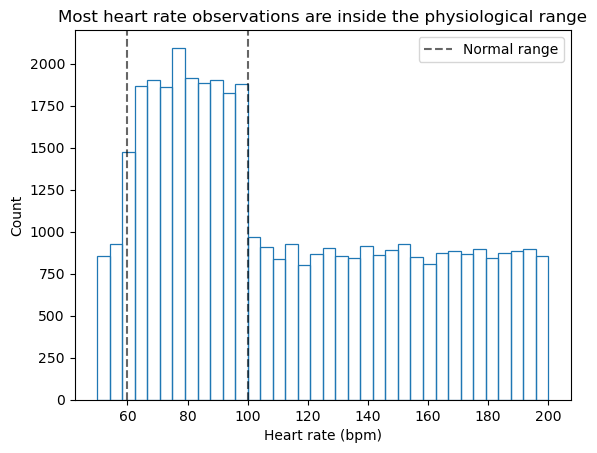

In [37]:
fig, ax = plt.subplots()
sns.histplot(
    data,
    fill = False
);
ax.set_xlabel(xx + ' (bpm)');
ax.axvline(physio_ranges[xx][0], ls='--', color='k', alpha=0.6)
ax.axvline(physio_ranges[xx][1], ls='--', color='k', alpha=0.6, label='Normal range')
ax.legend(loc='upper right')
ax.set_title('Most heart rate observations are inside the physiological range');

**Problema 2:** Viendo el describe de Heart rate, lo único que puedo darme cuenta es que el promedio se encuentra por encima del rango fisiológico. No es hasta que vemos la distribucion que nos damos cuenta que la mayoría de las observaciones sí se encuentra dentro del rango normal, y el promedio se está viendo desplazado por observaciones que exhiben una distribución más uniforme por encima del rago fisiológico.

## 5. Construir una figura multipanel (2×2) con tamaño y tipografía de publicación

In [38]:
data1 = (conditions
            [conditions['PATIENT'].isin(covid_mask)][['DESCRIPTION']]
            .value_counts()
            .drop('COVID-19', level=0)
            .reset_index(name='count')
            .head(20)
            .rename(columns={'DESCRIPTION': 'Illness'})
         )

death_mask = (covid
    .drop_duplicates(subset=['patient'])[['patient','deathdate']]
    .dropna(subset=['deathdate'])['patient']
    .reset_index(drop=True))
covid['death'] = covid['patient'].isin(death_mask)
xx = ['Diastolic Blood Pressure', 'Body Weight']
#covid[covid['obs_desc'].isin(xx)][['obs_desc', 'num_val', 'death', 'date']] #Platelets [#/volume] in Blood by Automated count

data2 = (covid
         [covid['obs_desc'].isin(xx)]
         .pivot_table(
             index = ['patient', 'death', 'date', 'median_age'],
             columns = 'obs_desc',
             values = 'num_val')
         .reset_index()
)

data3 = (covid
         .pivot_table(
             index = 'obs_code',
             columns = 'age_group',
             values = 'num_val',
             aggfunc = 'count',
             observed = False,
             dropna = False,
         )
    
)
threshold = 100
data3_filtered = data3[data3.sum(axis=1) >= threshold]
data3_filtered = data3_filtered.loc[:, data3_filtered.sum(axis=0) >= threshold] # quitar con menos de 100 observaciones

x4 = 'Platelets [#/volume] in Blood by Automated count'
data4 = covid[covid['obs_desc'] == x4][['date', 'num_val', 'covid_start']]

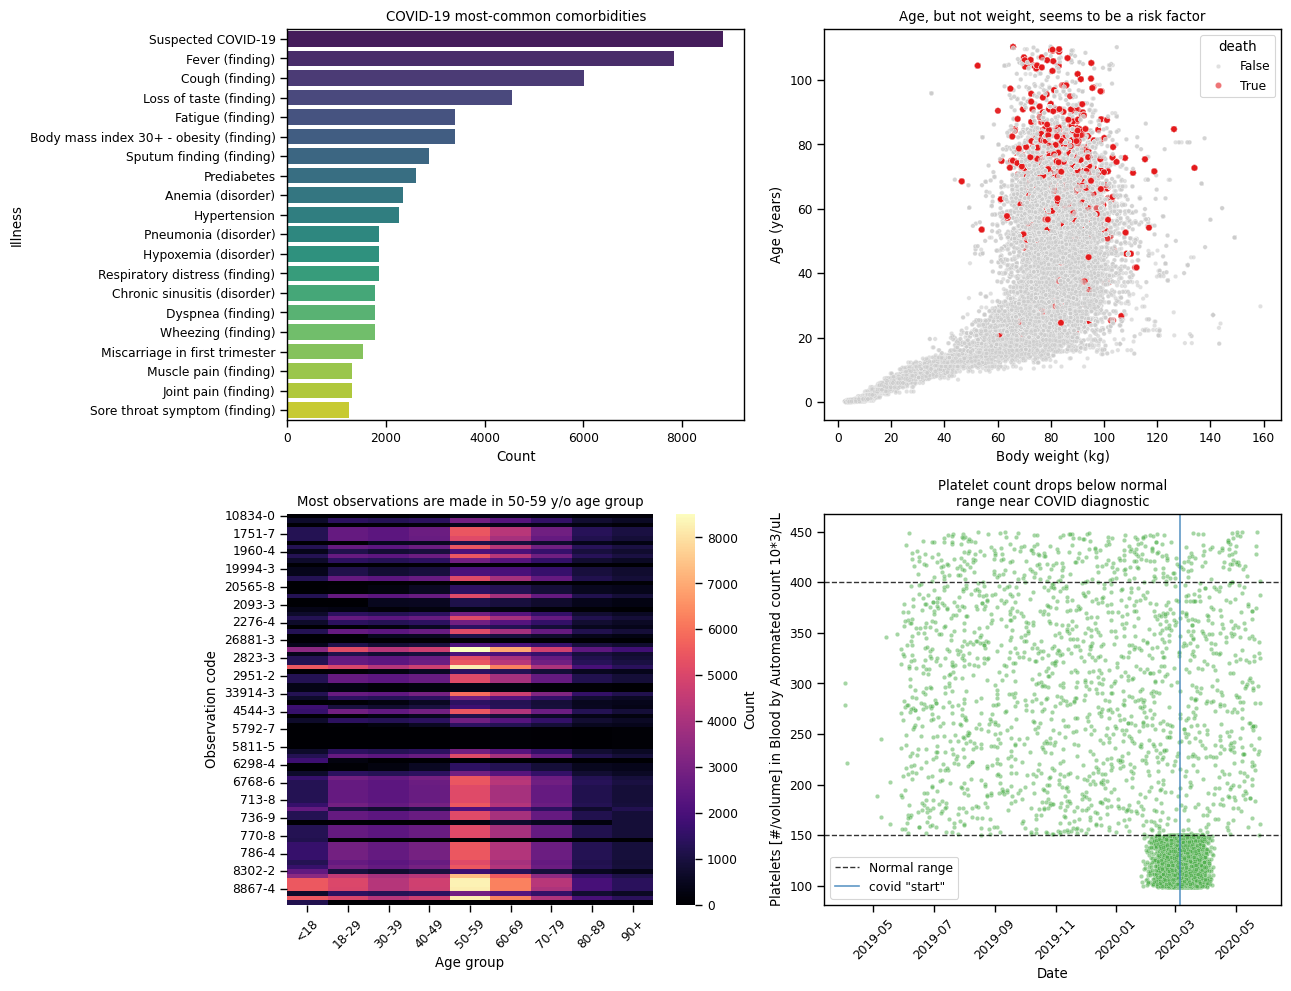

In [39]:
sns.set_context('paper')
fig, axs = plt.subplots(2, 2, figsize=(13,10))
axs = axs.flatten()
sns.barplot(
    data = data1,
    x = 'count',
    y = 'Illness',
    palette = 'viridis',
    hue = 'Illness',
    legend = False,
    ax = axs[0])
axs[0].set_title('COVID-19 most-common comorbidities');
axs[0].set_xlabel('Count')

sns.scatterplot(
    data = data2,
    x = 'Body Weight',
    y = 'median_age',
    hue = 'death',
    palette = {True: '#e41a1c', False: '#cccccc'},
    size = 'death',
    sizes = {True: 20, False: 10},
    alpha = 0.6,
    ax = axs[1]);
axs[1].set_ylabel('Age (years)')
axs[1].set_xlabel('Body weight (kg)');
axs[1].set_title('Age, but not weight, seems to be a risk factor');

sns.heatmap(
    data3_filtered,
    cmap='magma',
    cbar_kws={'label': 'Count'},
    ax = axs[2]);
axs[2].set_ylabel('Observation code')
axs[2].set_title('Most observations are made in 50-59 y/o age group')
axs[2].tick_params(axis='x', rotation=45)
axs[2].set_xlabel('Age group')

sns.scatterplot(
    data = data4,
    x = 'date',
    y = 'num_val',
    alpha = 0.5,
    s = 10,
    color = '#4daf4a',
    ax = axs[3])
axs[3].tick_params(axis='x', rotation=45)
axs[3].set_ylabel(x4 + ' 10*3/uL')
axs[3].axhline(physio_ranges[x4][0], ls='--', alpha=0.8, color='k', lw=1, label='Normal range')
axs[3].axhline(physio_ranges[x4][1], ls='--', alpha=0.8, color='k', lw=1)
axs[3].axvline(data4['covid_start'].dropna().median(), label='covid "start"', alpha=0.8, color='#377eb8')
axs[3].legend(loc='lower left')
axs[3].set_title('Platelet count drops below normal\nrange near COVID diagnostic');
axs[3].set_xlabel('Date');
fig.tight_layout();

## 6. Reproducir la misma figura clave en matplotlib puro, en seaborn y en plotly; comparar esfuerzo, control y resultado

#### Matplotlib

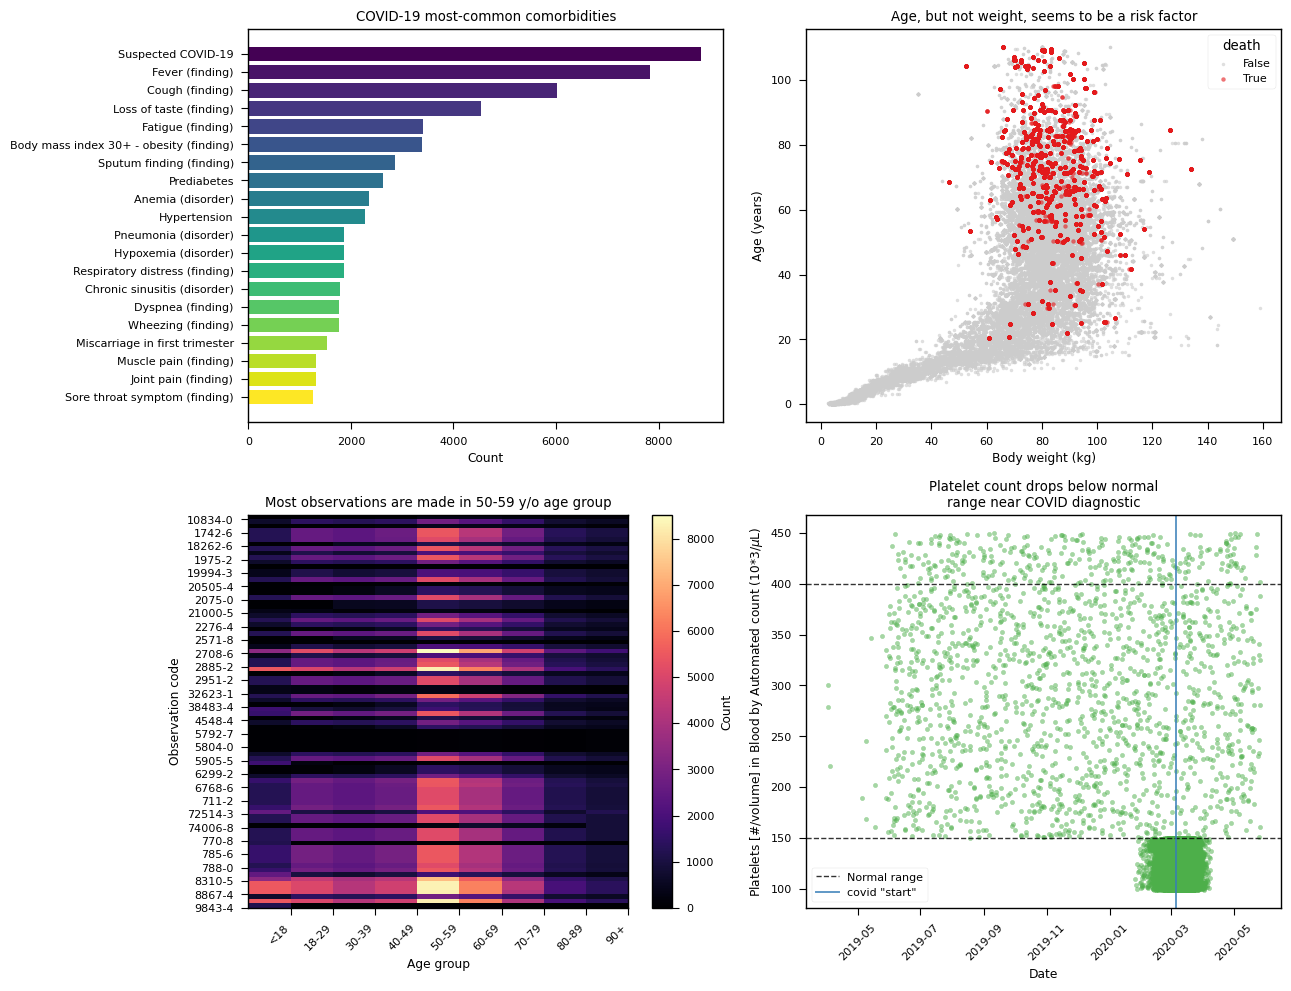

In [40]:
plt.style.use('seaborn-v0_8-paper')# if 'seaborn-v0_8-paper' in plt.style.available else 'default')
fig, axs = plt.subplots(2, 2, figsize=(13, 10))
axs = axs.flatten()

# -------------------------------------panel 1--------------------------------
data1_s = data1.iloc[::-1]
colors = matplotlib.cm.viridis_r(np.linspace(0, 1, len(data1_s)))
axs[0].barh(data1_s['Illness'],
            data1_s['count'],
            color=colors)
axs[0].set_title('COVID-19 most-common comorbidities')
axs[0].set_xlabel('Count');

# -------------------------------------panel 2--------------------------------
d2nodeath = data2[~data2['death']]
d2death = data2[data2['death']]
axs[1].scatter(d2nodeath['Body Weight'],
               d2nodeath['median_age'],
               color='#cccccc',
               s = 5,
               alpha = 0.6,
               label = 'False')
axs[1].scatter(d2death['Body Weight'],
               d2death['median_age'],
               color = '#e41a1c',
               s = 8,
               alpha = 0.6,
               label='True')
axs[1].set_ylabel('Age (years)')
axs[1].set_xlabel('Body weight (kg)')
axs[1].set_title('Age, but not weight, seems to be a risk factor');
axs[1].legend(title='death');

# -------------------------------------panel 3--------------------------------
im = axs[2].pcolormesh(
    np.arange(data3_filtered.shape[1]),
    np.arange(data3_filtered.shape[0]),
    data3_filtered.values,
    cmap = 'magma')
axs[2].set_xticks(np.arange(data3_filtered.shape[1]) + 0.5)
axs[2].set_yticks(np.arange(data3_filtered.shape[0]) + 0.5)
axs[2].set_xticklabels(data3_filtered.columns, rotation=45, ha='right')
axs[2].set_yticklabels(data3_filtered.index)
axs[2].invert_yaxis() 
cbar = fig.colorbar(im, ax=axs[2])
cbar.set_label('Count')
axs[2].set_ylabel('Observation code')
axs[2].set_xlabel('Age group');
axs[2].set_title('Most observations are made in 50-59 y/o age group');
ticks = axs[2].get_yticks()[::3]
axs[2].set_yticks(ticks);

# -------------------------------------panel 4--------------------------------

start = data4['covid_start'].dropna().median()
date = data4['date']
axs[3].scatter(
    date,
    data4['num_val'],
    color = '#4daf4a',
    s = 10,
    alpha = 0.5)
axs[3].tick_params(axis='x', rotation=45)
axs[3].set_ylabel(f'{x4} (10*3/$\mu$L)')
axs[3].set_xlabel('Date')
axs[3].axhline(physio_ranges[x4][0], ls='--', alpha=0.8, color='k', lw=1, label='Normal range')
axs[3].axhline(physio_ranges[x4][1], ls='--', alpha=0.8, color='k', lw=1)
axs[3].axvline(start, label='covid "start"', alpha=0.8, color='#377eb8')
axs[3].legend(loc='lower left');
axs[3].set_title('Platelet count drops below normal\nrange near COVID diagnostic');

fig.tight_layout();
#plt.savefig('fig1_cohort.pdf', format='pdf', bbox_inches='tight', transparent=True)

#### Seaborn

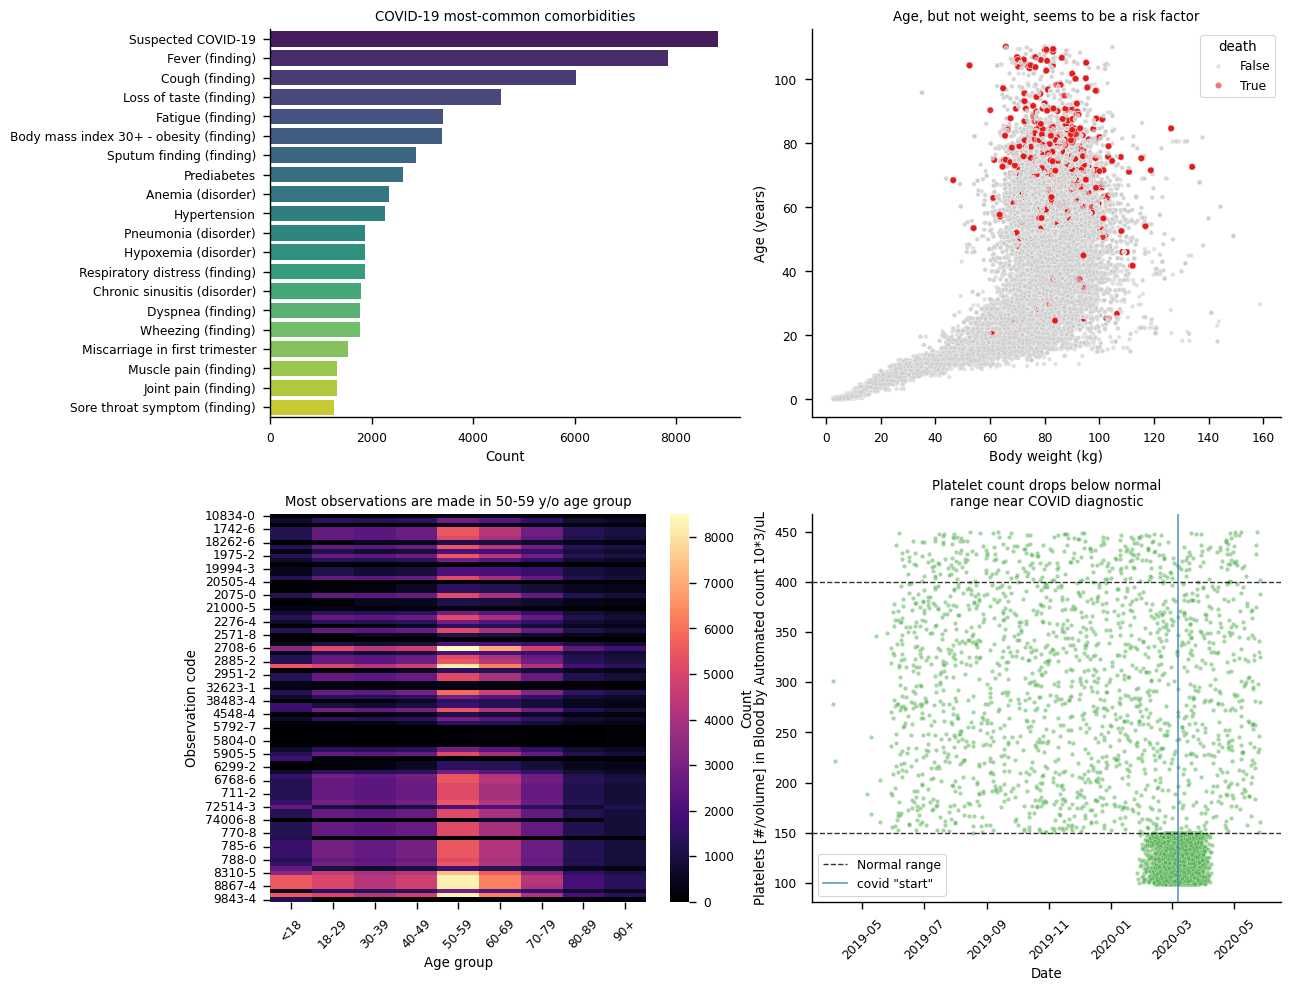

In [41]:
sns.set_context("paper")

g = sns.FacetGrid(pd.DataFrame({"plot": range(4)}),
                  col = "plot",
                  col_wrap = 2,
                  height = 5,
                  aspect = 1.3,
                  despine = True,
                  sharex = False,
                  sharey = False)

# -------------------------------------panel 1--------------------------------
sns.barplot(data = data1,
            x = "count",
            y = "Illness",
            hue = "Illness",
            palette = "viridis",
            legend = False,
            ax = g.axes[0])
g.axes[0].set_title("COVID-19 most-common comorbidities")
g.axes[0].set_xlabel("Count")
g.axes[0].set_ylabel("")

# -------------------------------------panel 2--------------------------------
sns.scatterplot(data = data2,
                x = "Body Weight",
                y = "median_age",
                hue = "death",
                palette = {True: "#e41a1c", False: "#cccccc"},
                size = "death",
                sizes = {True: 20, False: 10},
                alpha = 0.6,
                ax = g.axes[1])
g.axes[1].set_ylabel("Age (years)")
g.axes[1].set_xlabel("Body weight (kg)")
g.axes[1].set_title("Age, but not weight, seems to be a risk factor")

# -------------------------------------panel 3--------------------------------

sns.heatmap(data3_filtered,
            cmap = "magma",
            cbar_kws = {"label": "Count"},
            ax = g.axes[2])
g.axes[2].set_ylabel("Observation code")
g.axes[2].set_title("Most observations are made in 50-59 y/o age group")
g.axes[2].tick_params(axis="x", rotation=45)
g.axes[2].set_xlabel("Age group")

# -------------------------------------panel 4--------------------------------

sns.scatterplot(data = data4,
                x = "date",
                y = "num_val",
                alpha = 0.5,
                s = 10,
                color = "#4daf4a",
                ax = g.axes[3])
g.axes[3].tick_params(axis="x", rotation=45)
g.axes[3].set_ylabel(x4 + " 10*3/uL")
g.axes[3].axhline(physio_ranges[x4][0], ls="--", alpha=0.8, color="k", lw=1, label="Normal range")
g.axes[3].axhline(physio_ranges[x4][1], ls="--", alpha=0.8, color="k", lw=1)
g.axes[3].axvline(data4["covid_start"].dropna().median(), label='covid "start"', alpha=0.8, color="#377eb8")
g.axes[3].legend(loc="lower left")
g.axes[3].set_title("Platelet count drops below normal\nrange near COVID diagnostic")
g.axes[3].set_xlabel("Date");

#g.set_titles("")
g.figure.tight_layout();
#g.figure.subplots_adjust(hspace=0.3, wspace=0.25);

#### Plotly

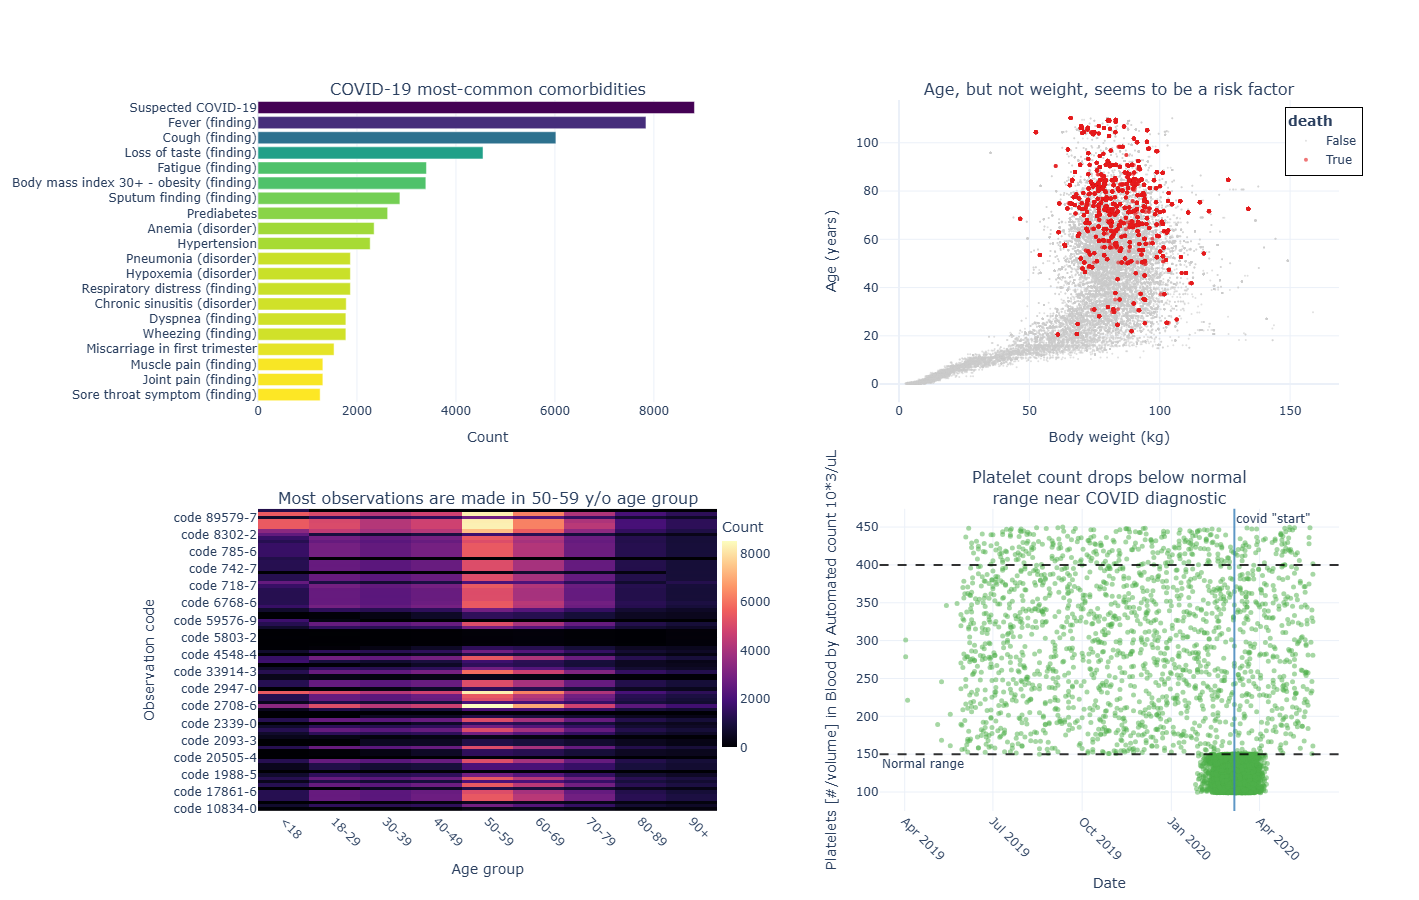

In [42]:
fig = make_subplots(
    rows = 2,
    cols = 2,
    subplot_titles = (
        'COVID-19 most-common comorbidities',
        'Age, but not weight, seems to be a risk factor',
        'Most observations are made in 50-59 y/o age group',
        'Platelet count drops below normal<br>range near COVID diagnostic'),
    horizontal_spacing = 0.15,
    vertical_spacing = 0.15)
fig.update_layout(
    height = 900,
    width = 1100,
    template = 'plotly_white',
    showlegend = True,
    legend = dict(
        title = dict(text='<b>death</b>'),
        x = 0.95,
        y = 0.99,
        bordercolor = 'Black',
        borderwidth=1))
# -------------------------------------panel 1--------------------------------
fig.add_trace(
    go.Bar(
        x = data1_s['count'],
        y = data1_s['Illness'],
        orientation = 'h',
        marker = dict(
            color = data1_s['count'],
            colorscale = 'Viridis_r',
            showscale = False),
        hovertemplate = '<b>%{y}</b><br>Count: %{x}<extra></extra>',
        showlegend = False),
    row = 1,
    col = 1)
fig.update_xaxes(title_text = 'Count', row=1, col=1)
# -------------------------------------panel 2--------------------------------
for death, color, size, label in [(False, '#cccccc', 2, 'False'), (True, '#e41a1c', 4, 'True')]:
    subset = data2[data2['death'] == death]
    fig.add_trace(
        go.Scatter(
            x = subset['Body Weight'],
            y = subset['median_age'],
            mode = 'markers',
            name = label,
            marker = dict(
                color = color,
                size=size,
                opacity=0.6),
            hovertemplate = 'Weight: %{x:.1f} kg<br>Age: %{y} yrs<extra></extra>'),
        row = 1,
        col = 2)
fig.update_xaxes(title_text = 'Body weight (kg)', row=1, col=2)
fig.update_yaxes(title_text = 'Age (years)', row=1, col=2)
# -------------------------------------panel 3--------------------------------
fig.add_trace(
    go.Heatmap(
        z = data3_filtered.values,
        y = list(map(lambda d: 'code ' + d, data3_filtered.index.astype('string').to_list())),
        x = [str(d) for d in data3_filtered.columns],
        colorscale = 'Magma',
        colorbar = dict(
            len = 0.35,
            title = 'Count',
            y = 0.25,
            x = 0.42,
            xanchor = 'left',
            thickness = 15),
        hovertemplate = 'Age: %{x}<br>Code: %{y}<br>Count: %{z}<extra></extra>'),
    row = 2,
    col = 1)
fig.update_xaxes(title_text = 'Age group', tickangle=45, row=2, col=1)
fig.update_yaxes(title_text = 'Observation code', autorange=True, row=2, col=1)
# -------------------------------------panel 4--------------------------------
fig.add_trace(
    go.Scatter(
        x = data4['date'],
        y = data4['num_val'],
        mode = 'markers',
        marker = dict(
            color = '#4daf4a',
            size = 5,
            opacity = 0.5),
        showlegend = False,
        hovertemplate = "Date: %{x}<br>Platelet count: %{y}<extra></extra>"),
    row = 2,
    col = 2)
fig.add_hline(
    y = physio_ranges[x4][0],
    line_dash = 'dash',
    line_color = 'black',
    opacity = 0.8,
    annotation_text = 'Normal range',
    annotation_position = 'bottom left',
    row = 2,
    col = 2)
fig.add_hline(
    y = physio_ranges[x4][1],
    line_dash = 'dash',
    line_color = 'black',
    opacity = 0.8,
    row = 2,
    col = 2)
ts = str(data4['covid_start'].dropna().median())
fig.add_vline(
    x = ts,
    line_dash = 'solid',
    line_color = '#377eb8',
    opacity = 0.8,
    row = 2,
    col = 2)
fig.add_annotation(
    x = ts,
    y = 1,
    yref = 'y4 domain',
    text = 'covid "start"',
    showarrow = False,
    xanchor = "left",
    yanchor = "top",
    row = 2,
    col = 2)
fig.update_xaxes(title_text = 'Date', tickangle=45, row=2, col=2)
fig.update_yaxes(title_text = f'{x4} 10*3/uL', title_standoff=15, row=2, col=2)

Comentarios: En cuanto a control y esfuerzo, seaborn y matplotlib los encuentro similares, siendo plotly ligeramente mas complicado. Es decir, a plotly le encuentro mayor control al costo de mayor esfuerzo, mientras que matplotlib y seaborn son mas similares entre ellos. En un ejemplo específico, plotly requiere que a cada elemento "individual" (un scatter, una linea, etc) se le especifique la fila y columna donde debe ser dibujado, mientras que en seaborn y en matplotlib es más directo acceder a cada panel mediante "axes". Esto implica mayor esfuerzo, pero tambien veo la ventaja de este control más manual de plotly. Por otro lado, seaborn cuenta con la gran ventaja de la compatibilidad muy directa con objetos pandas. En específico, facilita mucho la extracción de cada conjunto de datos que entrará a la gráfica y la separación de categorías mediante el parámetro "hue". Esto disminuye el esfuerzo requerido para seaborn, mientras que en matplotlib y plotly se debe extraer los datos "por fuera" en un paso extra. Pero si no se trabaja con objetos de pandas, esta ventaja se pierde. Finalmente, en cuanto a resultados, plotly es claramente superior por la ventaja de ser interactivo, a costo de ser el más lento de los 3 al momento de generar la figura. A mi parecer, lo ideal es trabajar en conjunto con matplotlib y seaborn, combinando el control de creación de objetos del primero con el poco esfuerzo requerido para el segundo para acceder a los datos de objetos de pandas. Por otro lado, plotly lo encuentro muy útil para ciertos tipos de gráficas donde la interactividad permite obtener información que de otra manera tendríamos que agregar como anotación. Por ejemplo, una gráfica de pastel donde la interactividad permita ver el codigo mas frecuente resulta bastante útil, mientras que un scatterplot donde la interactividad me permite acceder a todos y cada uno de los valores de conteo de Platelets no es tan útil y agrega mucho tiempo al momento de generar la gráfica.

## 7. Construir la tabla de características basales (Tabla 1) de tu cohorte

In [43]:
pats = covid.drop_duplicates(subset=['patient']).copy()
pd.crosstab(
    pats['gender'], 
    pats['death'], 
    margins = True, 
    margins_name = 'Total')

death,False,True,Total
gender,,,
F,4471,154,4625
M,3992,203,4195
Total,8463,357,8820


In [44]:
pd.crosstab(
    pats['gender'], 
    pats['death'], 
    normalize = 'columns',
    margins = True,
    margins_name = 'Total')*100

death,False,True,Total
gender,,,
F,52.829966,43.137255,52.437642
M,47.170034,56.862745,47.562358


In [45]:
def get_iqr(col):
    md = col.median()
    q25 = col.quantile(0.25)
    q75 = col.quantile(0.75)
    return f'md: {md:.1f}\tq25: {q25:.1f} \tq75: {q75:.1f}'

def get_mean_sd(col):
    mn = col.mean()
    s = col.std()
    return f'mn: {mn:.1f}\tsd: {s:.1f}'

In [46]:
t = pats['median_age']
a = t[~pats['death']]
d = t[pats['death']]
l = ('alive', 'deceased', 'total')
for j, i in enumerate((a,d,t)):
    print(l[j])
    print('Median:')
    print(get_iqr(i))
    print('Mean:')
    print(get_mean_sd(i))
    print('')
del t, a , d, l

alive
Median:
md: 39.8	q25: 21.2 	q75: 57.2
Mean:
mn: 40.2	sd: 23.1

deceased
Median:
md: 73.6	q25: 62.3 	q75: 83.9
Mean:
mn: 72.5	sd: 18.3

total
Median:
md: 41.3	q25: 22.2 	q75: 58.9
Mean:
mn: 41.5	sd: 23.8



In [47]:
# 777-3 platelets
# 785-6 mch
blood = pd.merge(pats[['patient', 'death']],
         (covid
             [covid['obs_code'].isin(('777-3', '785-6'))]
             .groupby(['patient', 'obs_code'])['num_val']
             .mean()
             .unstack(level='obs_code')
             .reset_index()
             .rename(columns={'777-3': 'mean_plat_count',
                             '785-6': 'mean_mch_count'})),
         on = 'patient',
         how = 'left'
        )

In [48]:
t = blood['mean_plat_count']
a = t[~blood['death']]
d = t[blood['death']]
l = ('alive', 'deceased', 'total')
for j, i in enumerate((a,d,t)):
    print(l[j])
    print('Median:')
    print(get_iqr(i))
    print('Mean:')
    print(get_mean_sd(i))
    print('')
del t, a , d, l

alive
Median:
md: 143.7	q25: 125.4 	q75: 295.8
Mean:
mn: 210.6	sd: 106.7

deceased
Median:
md: 125.3	q25: 122.3 	q75: 129.6
Mean:
mn: 128.1	sd: 13.9

total
Median:
md: 135.1	q25: 124.8 	q75: 277.5
Mean:
mn: 201.6	sd: 104.1



In [49]:
t = blood['mean_mch_count']
a = t[~blood['death']]
d = t[blood['death']]
l = ('alive', 'deceased', 'total')
for j, i in enumerate((a,d,t)):
    print(l[j])
    print('Median:')
    print(get_iqr(i))
    print('Mean:')
    print(get_mean_sd(i))
    print('')
del t, a , d, l

alive
Median:
md: 29.8	q25: 29.2 	q75: 30.5
Mean:
mn: 29.9	sd: 1.2

deceased
Median:
md: 29.8	q25: 29.4 	q75: 30.1
Mean:
mn: 29.8	sd: 0.5

total
Median:
md: 29.8	q25: 29.3 	q75: 30.4
Mean:
mn: 29.8	sd: 1.1



| Variable | Alive<br>(n=8463) | Deceased<br>(n=357) | Total<br>(n=8820) |
|:----------:|:-----------------:|:-------------------:|:-----------------:|
| **Sex** |
| Male | 3992 (47.2%) |   203 (56.9%) |  4195 (47.6%) |
| Female | 4771 (52.8%) |   154 (43.1%)  |  4625 (52.4%) |
| **Age (years)** |
| Mean (SD) | 40.2 (23.1) | 72.5 (18.3) | 41.5 (23.8) | 
| Median (IQR) | 39.8 (21.2-57.2) | 73.6 (62.3-83.9) | 41.3 (22.2-58.9) |
| **Platelet count (# * $10^3$/$\mu$L)** | 
| Median (IQR) | 143.7 (125.4-295.8) | 125.3 (122.3 - 129.6) | 135.1 (124.8 - 277.5) |
| **Mean corpuscular hemoglobin count (pg)** |
| Mean (SD) | 29.9 (1.2) | 29.8 (0.5) | 29.8 (1.1) | 

# Hallazgos clínicos:
1. El análisis longitudinal de la cohorte reveló que tras la presentación de COVID-19, los pacientes desarrollan desregulación hematológica marcada por trombocitopenia: conteos subnormales de plaquetas, de 100k-150k por $\mu$L de sangre, fueron observados en fechas cercanas al inicio clínico de la enfermedad. Rango fisiológico de referencia: 150k-400k plaquetas por $\mu$L de sangre. Pacientes con desenlace fatal tuvieron conteo de plaquetas mediano en estatus trombocitopenico agravado en comparación con pacientes sin desenlace fatal.
2. La edad cronológica avanzada también fue identificada como un factor de riesgo crítico: la mayoría de los desenlaces fatales relacionados con la enfermedad fueron registrados en pacientes mayores de 50 años. La edad promedio de pacientes con desenlace fatal fue de 72.5 años, en contraste con los 40.2 años promedio de pacientes sin desenlace fatal.
3. A lo largo del período de análisis, el monitoreo de los niveles hemoglobina corpuscular media (MCH) de los pacientes promedio de los pacientes (29.8 pg) se mantuvo dentro de los rangos fisiológicos de referencia (27-32 pg). Esta estabilidad fisiológica permitió que los pacientes mantuvieran niveles homestáticos de dicha variable, a pesar de la infección por COVID-19. No se encontró relación entre esta variable hematológica y la mortalidad de la cohorte.